In [1]:
import uproot
import numpy as np
import awkward as ak

In [2]:
tr_TTLJ = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")
tr_Vcb = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2018/Vcb_BTag_SPANet/Central_Syst/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree")

In [3]:
NEEDED = [
    "weight_b_tag",
    "weight_b_tag_up_cferr1",
    "weight_b_tag_up_cferr2",
    "weight_el_id",
    "weight_mc",
    "weight_lumi",
    "weight_mu_id",
    "weight_mu_iso",
    "weight_el_reco",
    "weight_pileup",
    "weight_prefire",
    "weight_sl_trig",
    "weight_top_pt",
    "weight_b_tag_up_hf",
    "genTtbarId",
    "template_score_MultiClass_log_prob_0",
    "template_score_MultiClass_log_prob_1",
    "template_score_MultiClass_log_prob_2",
    "template_score_MultiClass_log_prob_3",
]

# NEEDED = [
#     "weight_c_tag",
#     "weight_c_tag_up_xsec_brunc_dyjets_b",
#     "weight_c_tag_up_xsec_brunc_dyjets_c",
#     "weight_c_tag_up_xsec_brunc_wjets_c",
#     "weight_c_tag_up_stat",
#     "weight_el_id",
#     "weight_mc",
#     "weight_lumi",
#     "weight_mu_id",
#     "weight_mu_iso",
#     "weight_el_reco",
#     "weight_pileup",
#     "weight_prefire",
#     "weight_sl_trig",
#     "weight_top_pt",
#     "genTtbarId",
#     "template_score_MultiClass_log_prob_0",
#     "template_score_MultiClass_log_prob_1",
#     "template_score_MultiClass_log_prob_2",
#     "template_score_MultiClass_log_prob_3",
# ]

In [4]:
arr_TTLJ = tr_TTLJ.arrays(NEEDED,library="ak")
arr_Vcb = tr_Vcb.arrays(NEEDED,library="ak")

In [13]:
import itertools
import numpy as np
def get_grids(dim, low, high, res=10):
    base_grid = np.linspace(low, high, res)
    grid = itertools.product(base_grid, repeat=dim)
    return np.array(list(grid))

In [8]:
def _logsumexp(a, axis=None, keepdims=False):
    m = np.max(a, axis=axis, keepdims=True)
    m_safe = np.where(np.isfinite(m), m, 0.0)
    s = np.log(np.sum(np.exp(a - m_safe), axis=axis, keepdims=True)) + m_safe
    return s if keepdims else np.squeeze(s, axis=axis)

def _expit(x):
    # stable sigmoid
    x = np.asarray(x, dtype=np.float64)
    out = np.empty_like(x)
    pos = x >= 0
    out[pos]  = 1.0 / (1.0 + np.exp(-x[pos]))
    e = np.exp(x[~pos])
    out[~pos] = e / (1.0 + e)
    return out

def log_prob_to_weighted_prob(log_prob: np.ndarray, weights: np.ndarray) -> np.ndarray:
    """
    log_prob: (N, K)  — 각 샘플의 log p_j (log-softmax)
    weights : (K,)    — w_j (>0)
    반환: P_w(sig|x) = σ( log(w0 p0) - log Σ_{j≠0} wj pj )
    """
    logp = np.asarray(log_prob, dtype=np.float64)
    w    = np.asarray(weights,  dtype=np.float64)

    if logp.ndim != 2:
        raise ValueError("log_prob must be 2-D (N, K).")
    N, K = logp.shape
    if w.shape != (K,):
        raise ValueError(f"weights must have shape ({K},).")
    logw = np.log(w)
    # s = log(w0 p0) - logsumexp_j≠0 (log wj + log pj)
    s_num = logw[0] + logp[:, 0]
    s_den = _logsumexp(logp[:, 1:] + logw[1:][None, :], axis=1)
    s = s_num - s_den
    return _expit(s)

def asimov_Z(s, b, *, rel_b=None, sigma_b=None, clip_nonneg=True, eps=1e-12):
    """
    Asimov Z (Cowan+ 2011) 계산.
    Parameters
    ----------
    s : float or array-like
        신호 기대 이벤트 수.
    b : float or array-like
        배경 기대 이벤트 수.
    rel_b : float, optional
        배경 상대 불확도 (σ_b / b). sigma_b와 함께 주면 sigma_b가 우선.
    sigma_b : float or array-like, optional
        배경 절대 불확도 σ_b.
    clip_nonneg : bool, default True
        s, b, sigma_b < 0 인 값들을 0으로 올림.
    eps : float, default 1e-12
        수치 안정화용 작은 값.

    Returns
    -------
    Z : np.ndarray
    """
    s = np.asarray(s, dtype=float)
    b = np.asarray(b, dtype=float)

    if clip_nonneg:
        s = np.maximum(s, 0.0)
        b = np.maximum(b, 0.0)

    if sigma_b is not None:
        sigma_b = np.asarray(sigma_b, dtype=float)
        if clip_nonneg:
            sigma_b = np.maximum(sigma_b, 0.0)
    elif rel_b is not None:
        sigma_b = np.maximum(0.0, float(rel_b)) * b
    else:
        sigma_b = np.zeros_like(b)

    Z = np.zeros_like(s, dtype=float)

    # 케이스 1: 순수 통계 (σ_b == 0)
    mask_pure = sigma_b <= eps
    if np.any(mask_pure):
        s1 = s[mask_pure]; b1 = b[mask_pure]
        term = (s1 + b1) * np.log1p(s1 / (b1 + eps)) - s1
        Z[mask_pure] = np.sqrt(np.maximum(0.0, 2.0 * term))

    # 케이스 2: 시스템틱 포함 (σ_b > 0)
    mask_sys = ~mask_pure
    if np.any(mask_sys):
        s2 = s[mask_sys]; b2 = b[mask_sys]; sb2 = sigma_b[mask_sys]**2

        num1  = (s2 + b2) * (b2 + sb2)
        den1  = (b2**2) + (s2 + b2) * sb2
        term1 = (s2 + b2) * (np.log(num1 + eps) - np.log(den1 + eps))

        num2  = sb2 * s2
        den2  = b2 * (b2 + sb2) + eps
        term2 = (b2**2 / (sb2 + eps)) * np.log1p(num2 / den2)

        val = 2.0 * (term1 - term2)
        Z[mask_sys] = np.sqrt(np.maximum(0.0, val))

    # NaN/Inf 방지
    Z = np.where(np.isfinite(Z), Z, 0.0)
    return Z

In [7]:
def asimov_Z(s, b, *, rel_b=0.0, include_systematics=False,
             clip_nonneg=True, eps=1e-12):
    """
    벡터화된 Asimov Z.
      - include_systematics=False: Z0 = sqrt(2 * [(s+b) ln(1+s/b) - s])
      - include_systematics=True : Cowan+ (2011) eq. (71) (배경 가우시안 제약)
        여기서는 σ_b = rel_b * b (rel_b는 스칼라 or 벡터)
    """
    s = np.asarray(s, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if clip_nonneg:
        s = np.maximum(s, 0.0)
        b = np.maximum(b, 0.0)

    # no-syst 케이스
    def _Z0(ss, bb):
        with np.errstate(divide='ignore', invalid='ignore'):
            val = 2.0 * ((ss + bb) * np.log(1.0 + ss / (bb + eps)) - ss)
        return np.sqrt(np.maximum(val, 0.0))

    if not include_systematics:
        Z = _Z0(s, b)
        Z[~np.isfinite(Z)] = 0.0
        return Z

    # syst 포함 (배경만): σ_b^2 = (rel_b * b)^2
    rb = np.asarray(rel_b, dtype=np.float64)
    sigma2 = (rb * b) ** 2

    Z2 = np.zeros_like(s, dtype=np.float64)
    mask = sigma2 > eps
    if np.any(mask):
        ss = s[mask]; bb = b[mask]; sig2 = sigma2[mask]
        with np.errstate(divide='ignore', invalid='ignore'):
            term1 = (ss + bb) * np.log(((ss + bb) * (bb + sig2)) / (bb * bb + (ss + bb) * sig2 + eps) + eps)
            term2 = (bb * bb / sig2) * np.log(1.0 + (sig2 * ss) / (bb * (bb + sig2) + eps) + eps)
            Z2[mask] = 2.0 * np.maximum(0.0, term1 - term2)
    # sigma2 ~ 0 인 곳은 no-syst 공식을 사용
    if np.any(~mask):
        Z2[~mask] = ( _Z0(s[~mask], b[~mask]) ) ** 2

    Z = np.sqrt(np.maximum(Z2, 0.0))
    Z[~np.isfinite(Z)] = 0.0
    return Z

In [8]:

def _cum_from_right(h):
    # bins-1 길이의 히스토그램을 오른쪽 테일 누적으로 바꿉니다.
    return np.cumsum(h[::-1], dtype=np.float64)[::-1]

In [5]:

Vcb={}
TTLJ={}

Vcb['weight_b_tag'] = arr_Vcb['weight_b_tag'].to_numpy()
Vcb['weight_b_tag_up_cferr1'] = arr_Vcb['weight_b_tag_up_cferr1'].to_numpy()
Vcb['weight_b_tag_up_cferr2'] = arr_Vcb['weight_b_tag_up_cferr2'].to_numpy()
Vcb['weight_b_tag_up_hf'] = arr_Vcb['weight_b_tag_up_hf'].to_numpy()
Vcb['weight_el_id'] = arr_Vcb['weight_el_id'].to_numpy()
Vcb['weight_mc'] = arr_Vcb['weight_mc'].to_numpy()
Vcb['weight_lumi'] = arr_Vcb['weight_lumi'].to_numpy()
Vcb['weight_mu_id'] = arr_Vcb['weight_mu_id'].to_numpy()
Vcb['weight_mu_iso'] = arr_Vcb['weight_mu_iso'].to_numpy()
Vcb['weight_el_reco'] = arr_Vcb['weight_el_reco'].to_numpy()
Vcb['weight_pileup'] = arr_Vcb['weight_pileup'].to_numpy()
Vcb['weight_prefire'] = arr_Vcb['weight_prefire'].to_numpy()
Vcb['weight_sl_trig'] = arr_Vcb['weight_sl_trig'].to_numpy()
Vcb['weight_top_pt'] = arr_Vcb['weight_top_pt'].to_numpy()
Vcb['genTtbarId'] = arr_Vcb['genTtbarId'].to_numpy()
Vcb['TTBB_Mask'] = (Vcb['genTtbarId'] % 100 >= 51) & (Vcb['genTtbarId'] % 100 <= 55)
Vcb['TTCC_Mask'] = (Vcb['genTtbarId'] % 100 >= 41) & (Vcb['genTtbarId'] % 100 <= 45)
Vcb['weight_base'] = Vcb['weight_b_tag'] * Vcb['weight_el_id'] * Vcb['weight_mc'] * Vcb['weight_lumi'] * Vcb['weight_mu_id'] * Vcb['weight_mu_iso'] * Vcb['weight_el_reco'] * Vcb['weight_pileup'] * Vcb['weight_prefire'] * Vcb['weight_sl_trig'] * Vcb['weight_top_pt']
Vcb['weight_cferr1_up'] = Vcb['weight_base'] * Vcb['weight_b_tag_up_cferr1'] / Vcb['weight_b_tag']
Vcb['weight_cferr2_up'] = Vcb['weight_base'] * Vcb['weight_b_tag_up_cferr2'] / Vcb['weight_b_tag']
Vcb['weight_ttbb_up'] = Vcb['weight_base'] * np.where(Vcb['TTBB_Mask'], 1.1, 1.0)
Vcb['weight_ttcc_up'] = Vcb['weight_base'] * np.where(Vcb['TTCC_Mask'], 1.15, 1.0)
Vcb['classif_0'] = arr_Vcb['template_score_MultiClass_log_prob_0'].to_numpy()
Vcb['classif_1'] = arr_Vcb['template_score_MultiClass_log_prob_1'].to_numpy()
Vcb['classif_2'] = arr_Vcb['template_score_MultiClass_log_prob_2'].to_numpy()
Vcb['classif_3'] = arr_Vcb['template_score_MultiClass_log_prob_3'].to_numpy()


TTLJ['weight_b_tag'] = arr_TTLJ['weight_b_tag'].to_numpy()
TTLJ['weight_b_tag_up_cferr1'] = arr_TTLJ['weight_b_tag_up_cferr1'].to_numpy()
TTLJ['weight_b_tag_up_cferr2'] = arr_TTLJ['weight_b_tag_up_cferr2'].to_numpy()
TTLJ['weight_b_tag_up_hf'] = arr_TTLJ['weight_b_tag_up_hf'].to_numpy()
TTLJ['weight_el_id'] = arr_TTLJ['weight_el_id'].to_numpy()
TTLJ['weight_mc'] = arr_TTLJ['weight_mc'].to_numpy()
TTLJ['weight_lumi'] = arr_TTLJ['weight_lumi'].to_numpy()
TTLJ['weight_mu_id'] = arr_TTLJ['weight_mu_id'].to_numpy()
TTLJ['weight_mu_iso'] = arr_TTLJ['weight_mu_iso'].to_numpy()
TTLJ['weight_el_reco'] = arr_TTLJ['weight_el_reco'].to_numpy()
TTLJ['weight_pileup'] = arr_TTLJ['weight_pileup'].to_numpy()
TTLJ['weight_prefire'] = arr_TTLJ['weight_prefire'].to_numpy()
TTLJ['weight_sl_trig'] = arr_TTLJ['weight_sl_trig'].to_numpy()
TTLJ['weight_top_pt'] = arr_TTLJ['weight_top_pt'].to_numpy()
TTLJ['genTtbarId'] = arr_TTLJ['genTtbarId'].to_numpy()
TTLJ['TTBB_Mask'] = (TTLJ['genTtbarId'] % 100 >= 51) & (TTLJ['genTtbarId'] % 100 <= 55)
TTLJ['TTCC_Mask'] = (TTLJ['genTtbarId'] % 100 >= 41) & (TTLJ['genTtbarId'] % 100 <= 45)
TTLJ['weight_base'] = TTLJ['weight_b_tag'] * TTLJ['weight_el_id'] * TTLJ['weight_mc'] * TTLJ['weight_lumi'] * TTLJ['weight_mu_id'] * TTLJ['weight_mu_iso'] * TTLJ['weight_el_reco'] * TTLJ['weight_pileup'] * TTLJ['weight_prefire'] * TTLJ['weight_sl_trig'] * TTLJ['weight_top_pt']
TTLJ['weight_cferr1_up'] = TTLJ['weight_base'] * TTLJ['weight_b_tag_up_cferr1'] / TTLJ['weight_b_tag']
TTLJ['weight_cferr2_up'] = TTLJ['weight_base'] * TTLJ['weight_b_tag_up_cferr2'] / TTLJ['weight_b_tag']
TTLJ['weight_ttbb_up'] = TTLJ['weight_base'] * np.where(TTLJ['TTBB_Mask'], 1.1, 1.0)
TTLJ['weight_ttcc_up'] = TTLJ['weight_base'] * np.where(TTLJ['TTCC_Mask'], 1.15, 1.0)
TTLJ['weight_hf_up'] = TTLJ['weight_base'] * TTLJ['weight_b_tag_up_hf'] / TTLJ['weight_b_tag']
TTLJ['weight_top_pt_up'] = TTLJ['weight_base'] / TTLJ['weight_top_pt']
TTLJ['classif_0'] = arr_TTLJ['template_score_MultiClass_log_prob_0'].to_numpy()
TTLJ['classif_1'] = arr_TTLJ['template_score_MultiClass_log_prob_1'].to_numpy()
TTLJ['classif_2'] = arr_TTLJ['template_score_MultiClass_log_prob_2'].to_numpy()
TTLJ['classif_3'] = arr_TTLJ['template_score_MultiClass_log_prob_3'].to_numpy()


In [12]:
# C Tag version
grids = get_grids(3, 0.01, 1)

Vcb={}
TTLJ={}

Vcb['weight_c_tag'] = arr_Vcb['weight_c_tag'].to_numpy()
Vcb['weight_c_tag_up_xsec_brunc_dyjets_b'] = arr_Vcb['weight_c_tag_up_xsec_brunc_dyjets_b'].to_numpy()
Vcb['weight_c_tag_up_xsec_brunc_dyjets_c'] = arr_Vcb['weight_c_tag_up_xsec_brunc_dyjets_c'].to_numpy()
Vcb['weight_c_tag_up_xsec_brunc_wjets_c'] = arr_Vcb['weight_c_tag_up_xsec_brunc_wjets_c'].to_numpy()
Vcb['weight_c_tag_up_stat'] = arr_Vcb['weight_c_tag_up_stat'].to_numpy()
Vcb['weight_el_id'] = arr_Vcb['weight_el_id'].to_numpy()
Vcb['weight_mc'] = arr_Vcb['weight_mc'].to_numpy()
Vcb['weight_lumi'] = arr_Vcb['weight_lumi'].to_numpy()
Vcb['weight_mu_id'] = arr_Vcb['weight_mu_id'].to_numpy()
Vcb['weight_mu_iso'] = arr_Vcb['weight_mu_iso'].to_numpy()
Vcb['weight_el_reco'] = arr_Vcb['weight_el_reco'].to_numpy()
Vcb['weight_pileup'] = arr_Vcb['weight_pileup'].to_numpy()
Vcb['weight_prefire'] = arr_Vcb['weight_prefire'].to_numpy()
Vcb['weight_sl_trig'] = arr_Vcb['weight_sl_trig'].to_numpy()
Vcb['weight_top_pt'] = arr_Vcb['weight_top_pt'].to_numpy()
Vcb['genTtbarId'] = arr_Vcb['genTtbarId'].to_numpy()
Vcb['TTBB_Mask'] = (Vcb['genTtbarId'] % 100 >= 51) & (Vcb['genTtbarId'] % 100 <= 55)
Vcb['TTCC_Mask'] = (Vcb['genTtbarId'] % 100 >= 41) & (Vcb['genTtbarId'] % 100 <= 45)
Vcb['weight_base'] = Vcb['weight_c_tag'] * Vcb['weight_el_id'] * Vcb['weight_mc'] * Vcb['weight_lumi'] * Vcb['weight_mu_id'] * Vcb['weight_mu_iso'] * Vcb['weight_el_reco'] * Vcb['weight_pileup'] * Vcb['weight_prefire'] * Vcb['weight_sl_trig'] * Vcb['weight_top_pt']
Vcb['weight_ttbb_up'] = Vcb['weight_base'] * np.where(Vcb['TTBB_Mask'], 1.1, 1.0)
Vcb['weight_ttcc_up'] = Vcb['weight_base'] * np.where(Vcb['TTCC_Mask'], 1.15, 1.0)
Vcb['classif_0'] = arr_Vcb['template_score_MultiClass_log_prob_0'].to_numpy()
Vcb['classif_1'] = arr_Vcb['template_score_MultiClass_log_prob_1'].to_numpy()
Vcb['classif_2'] = arr_Vcb['template_score_MultiClass_log_prob_2'].to_numpy()
Vcb['classif_3'] = arr_Vcb['template_score_MultiClass_log_prob_3'].to_numpy()


TTLJ['weight_c_tag'] = arr_TTLJ['weight_c_tag'].to_numpy()
TTLJ['weight_c_tag_up_xsec_brunc_dyjets_b'] = arr_TTLJ['weight_c_tag_up_xsec_brunc_dyjets_b'].to_numpy()
TTLJ['weight_c_tag_up_xsec_brunc_dyjets_c'] = arr_TTLJ['weight_c_tag_up_xsec_brunc_dyjets_c'].to_numpy()
TTLJ['weight_c_tag_up_xsec_brunc_wjets_c'] = arr_TTLJ['weight_c_tag_up_xsec_brunc_wjets_c'].to_numpy()
TTLJ['weight_c_tag_up_stat'] = arr_TTLJ['weight_c_tag_up_stat'].to_numpy()
TTLJ['weight_el_id'] = arr_TTLJ['weight_el_id'].to_numpy()
TTLJ['weight_mc'] = arr_TTLJ['weight_mc'].to_numpy()
TTLJ['weight_lumi'] = arr_TTLJ['weight_lumi'].to_numpy()
TTLJ['weight_mu_id'] = arr_TTLJ['weight_mu_id'].to_numpy()
TTLJ['weight_mu_iso'] = arr_TTLJ['weight_mu_iso'].to_numpy()
TTLJ['weight_el_reco'] = arr_TTLJ['weight_el_reco'].to_numpy()
TTLJ['weight_pileup'] = arr_TTLJ['weight_pileup'].to_numpy()
TTLJ['weight_prefire'] = arr_TTLJ['weight_prefire'].to_numpy()
TTLJ['weight_sl_trig'] = arr_TTLJ['weight_sl_trig'].to_numpy()
TTLJ['weight_top_pt'] = arr_TTLJ['weight_top_pt'].to_numpy()
TTLJ['genTtbarId'] = arr_TTLJ['genTtbarId'].to_numpy()
TTLJ['TTBB_Mask'] = (TTLJ['genTtbarId'] % 100 >= 51) & (TTLJ['genTtbarId'] % 100 <= 55)
TTLJ['TTCC_Mask'] = (TTLJ['genTtbarId'] % 100 >= 41) & (TTLJ['genTtbarId'] % 100 <= 45)
TTLJ['weight_base'] = TTLJ['weight_c_tag'] * TTLJ['weight_el_id'] * TTLJ['weight_mc'] * TTLJ['weight_lumi'] * TTLJ['weight_mu_id'] * TTLJ['weight_mu_iso'] * TTLJ['weight_el_reco'] * TTLJ['weight_pileup'] * TTLJ['weight_prefire'] * TTLJ['weight_sl_trig'] * TTLJ['weight_top_pt']
TTLJ['weight_ttbb_up'] = TTLJ['weight_base'] * np.where(TTLJ['TTBB_Mask'], 1.1, 1.0)
TTLJ['weight_ttcc_up'] = TTLJ['weight_base'] * np.where(TTLJ['TTCC_Mask'], 1.15, 1.0)
TTLJ['weight_c_tag_stat_up'] = TTLJ['weight_base'] / TTLJ['weight_c_tag'] * TTLJ['weight_c_tag_up_stat']
TTLJ['weight_c_tag_xsec_dyjets_b_up'] = TTLJ['weight_base'] * TTLJ['weight_c_tag_up_xsec_brunc_dyjets_b'] / TTLJ['weight_c_tag']
TTLJ['weight_c_tag_xsec_dyjets_c_up'] = TTLJ['weight_base'] * TTLJ['weight_c_tag_up_xsec_brunc_dyjets_c'] / TTLJ['weight_c_tag']
TTLJ['weight_c_tag_xsec_wjets_c_up'] = TTLJ['weight_base'] * TTLJ['weight_c_tag_up_xsec_brunc_wjets_c'] / TTLJ['weight_c_tag']
TTLJ['classif_0'] = arr_TTLJ['template_score_MultiClass_log_prob_0'].to_numpy()
TTLJ['classif_1'] = arr_TTLJ['template_score_MultiClass_log_prob_1'].to_numpy()
TTLJ['classif_2'] = arr_TTLJ['template_score_MultiClass_log_prob_2'].to_numpy()
TTLJ['classif_3'] = arr_TTLJ['template_score_MultiClass_log_prob_3'].to_numpy()


FieldNotFoundError: no field 'weight_c_tag' in record with 19 fields

In [ ]:
import os
import numpy as np
from dataclasses import dataclass
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from ray import tune
from ray.air import session

# --- your existing bits (unchanged) ---
bins = np.linspace(0, 1, 1000)
grids = get_grids(3, 0.001, 10, res=10)  # 3D 그리드로 변경

@dataclass
class GridScanRecord:
    weights: np.ndarray   # (K,)
    best_Z: float
    best_thr: float
    best_S: float
    best_B: float
    best_rel_b: float
    i_best: int

# assumes you already have:
# - grids
# - Vcb, TTLJ dicts with arrays
# - log_prob_to_weighted_prob(...)
# - _cum_from_right(...)
# - asimov_Z(...)
def evaluate_config(config, Vcb_ref=None, TTLJ_ref=None, bins_ref=None, working_mode = 'b'):
    # 큰 객체는 ObjectRef로 들어오므로 여기서 꺼냄 (zero-copy 공유)
    Vcb  = ray.get(Vcb_ref)  if isinstance(Vcb_ref,  ray.ObjectRef) else Vcb_ref
    TTLJ = ray.get(TTLJ_ref) if isinstance(TTLJ_ref, ray.ObjectRef) else TTLJ_ref
    bins = ray.get(bins_ref) if isinstance(bins_ref, ray.ObjectRef) else bins_ref

    # ---- 이하 기존 로직 그대로 ----
    w = np.array([1.0,
                  config["w1"],
                  config["w2"],
                  config["w3"]], dtype=np.float64)

    Vcb_prob  = log_prob_to_weighted_prob(
        np.vstack([Vcb['classif_0'], Vcb['classif_1'], Vcb['classif_2'], Vcb['classif_3']]).T, w
    )
    TTLJ_prob = log_prob_to_weighted_prob(
        np.vstack([TTLJ['classif_0'], TTLJ['classif_1'], TTLJ['classif_2'], TTLJ['classif_3']]).T, w
    )


    Vcb_hist,  _ = np.histogram(Vcb_prob,  bins=bins, weights=Vcb['weight_base'])
    TTLJ_hist, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_base'])

    Vcb_hist_nMC, _ = np.historam(Vcb_prob, bins=bins, weights=np.ones_like(Vcb_prob))
    TTLJ_hist_nMC, _ = np.histogram(TTLJ_prob, bins=bins, weights=np.ones_like(TTLJ_prob))
    Vcb_hist_SumW2, _ = np.histogram(Vcb_prob, bins=bins, weights=Vcb['weight_base']**2)
    TTLJ_hist_SumW2, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_base']**2)

    S_cum = _cum_from_right(Vcb_hist)
    B_cum = _cum_from_right(TTLJ_hist)
    
    S_cum_nMC = _cum_from_right(Vcb_hist_nMC)
    B_sum_nMC = _cum_from_right(TTLJ_hist_nMC)

    S_cum_SumW2 = _cum_from_right(Vcb_hist_SumW2)
    B_sum_SumW2 = _cum_from_right(TTLJ_hist_SumW2)
    
    S_neff_cum = S_cum**2 / np.maximum(S_cum_SumW2, 1e-12)
    B_neff_cum = B_cum**2 / np.maximum(B_sum_SumW2, 1e-12)
    
    if working_mode == 'b':
        TTLJ_hist_cferr1_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_cferr1_up'])
        TTLJ_hist_cferr2_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_cferr2_up'])
        TTLJ_hist_ttbb_up,   _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_ttbb_up'])
        TTLJ_hist_ttcc_up,   _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_ttcc_up'])
        TTLJ_hist_top_pt_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_top_pt_up'])
        TTLJ_hist_hf_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_hf_up'])
        

        B_cferr1_cum = _cum_from_right(TTLJ_hist_cferr1_up)
        B_cferr2_cum = _cum_from_right(TTLJ_hist_cferr2_up)
        B_ttbb_cum   = _cum_from_right(TTLJ_hist_ttbb_up)
        B_ttcc_cum   = _cum_from_right(TTLJ_hist_ttcc_up)
        B_top_pt_cum = _cum_from_right(TTLJ_hist_top_pt_up)
        B_hf_cum = _cum_from_right(TTLJ_hist_hf_up)
        

        d_cferr1 = B_cferr1_cum - B_cum
        d_cferr2 = B_cferr2_cum - B_cum
        d_ttbb   = B_ttbb_cum   - B_cum
        d_ttcc   = B_ttcc_cum   - B_cum
        d_top_pt = B_top_pt_cum - B_cum
        d_hf = B_hf_cum - B_cum

        sigma_b = np.sqrt(d_cferr1**2 + d_cferr2**2 + d_ttbb**2 + d_ttcc**2 + d_top_pt**2 + d_hf**2)
    elif working_mode == 'c':
        TTLJ_hist_c_stat_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_c_tag_up_stat'])
        TTLJ_hist_c_brunc_dyjets_b, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_c_tag_up_xsec_brunc_dyjets_b'])
        TTLJ_hist_c_brunc_dyjets_c, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_c_tag_up_xsec_brunc_dyjets_c'])
        TTLJ_hist_c_brunc_wjets_c, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_c_tag_up_xsec_brunc_wjets_c'])
        TTLJ_hist_ttbb_up,   _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_ttbb_up'])
        TTLJ_hist_ttcc_up,   _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_ttcc_up'])
         
        B_c_stat_cum = _cum_from_right(TTLJ_hist_c_stat_up)
        B_c_brunc_dyjets_b_cum = _cum_from_right(TTLJ_hist_c_brunc_dyjets_b)
        B_c_brunc_dyjets_c_cum = _cum_from_right(TTLJ_hist_c_brunc_dyjets_c)
        B_c_brunc_wjets_c_cum = _cum_from_right(TTLJ_hist_c_brunc_wjets_c)
        B_ttbb_cum   = _cum_from_right(TTLJ_hist_ttbb_up)
        B_ttcc_cum   = _cum_from_right(TTLJ_hist_ttcc_up)

        d_c_stat = B_c_stat_cum - B_cum
        d_c_brunc_dyjets_c = B_c_brunc_dyjets_c_cum - B_cum
        d_c_brunc_dyjets_b = B_c_brunc_dyjets_b_cum - B_cum
        d_c_brunc_wjets_c = B_c_brunc_wjets_c_cum - B_cum
        d_ttbb = B_ttbb_cum - B_cum
        d_ttcc = B_ttcc_cum - B_cum

        sigma_b = np.sqrt(
            d_c_stat**2 +
            d_c_brunc_dyjets_b**2 +
            d_c_brunc_dyjets_c**2 +
            d_c_brunc_wjets_c**2 +
            d_ttbb**2 +
            d_ttcc**2
        )
    rel_b   = sigma_b / np.maximum(B_cum, 1e-12)

    Z_curve = asimov_Z(S_cum, B_cum, rel_b=rel_b, include_systematics=True)
    valid = np.isfinite(Z_curve) & (S_cum > 0) & (B_cum > 0) & (S_neff_cum > 20) & (B_neff_cum > 20)
    if not np.any(valid):
        session.report({"best_Z": -np.inf})
        return

    i_best = int(np.nanargmax(np.where(valid, Z_curve, -np.inf)))

    # ✅ dict로 한 번에 보고 + 메트릭 이름 통일(best_Z)
    session.report({
        "best_Z": float(Z_curve[i_best]),
        "thr":    float(bins[i_best]),
        "S":      float(S_cum[i_best]),
        "B":      float(B_cum[i_best]),
        "rel_b":  float(rel_b[i_best]),
        "w0":     float(w[0]), "w1": float(w[1]), "w2": float(w[2]), "w3": float(w[3]),
    })

import os, ray
from ray import tune
from ray.tune import Tuner, TuneConfig
from ray.tune.search.optuna import OptunaSearch
# from ray.tune.search.bayesopt import BayesOptSearch  # skopt 필요


In [16]:
if __name__ == "__main__":
    # Ray 초기화
    ray.shutdown()
    os.environ["RAY_TMPDIR"] = "/data6/tmp/ray"
    ray.init(include_dashboard=False, num_cpus=os.cpu_count() // 2)
    
    # 데이터 준비
    Vcb_ref = ray.put(Vcb)
    TTLJ_ref = ray.put(TTLJ)
    bins_ref = ray.put(bins)
    
    # 방법 1: 특정 포인트들만 테스트하고 싶다면
    # POINTS = [
    #     {"w1": 1.0, "w2": 1.0, "w3": 1.0},
    #     {"w1": 0.505059036132024, "w2": 1.6680193466624715, "w3": 7.817965331480203},
    # ]
    
    # param_space_grid = {
    #     "_point": tune.grid_search(POINTS)
    # }
    
    # def trainable_grid(config, Vcb_ref=None, TTLJ_ref=None, bins_ref=None, working_mode='c'):
    #     cfg = config["_point"]  # {'w1':..., 'w2':..., 'w3':...}
    #     return evaluate_config(cfg, Vcb_ref=Vcb_ref, TTLJ_ref=TTLJ_ref, bins_ref=bins_ref, working_mode=working_mode)
    
    # trainable = tune.with_parameters(
    #     trainable_grid,
    #     Vcb_ref=Vcb_ref, 
    #     TTLJ_ref=TTLJ_ref, 
    #     bins_ref=bins_ref, 
    #     working_mode='b'
    # )
    
    # # Grid search용 tuner (OptunaSearch 불필요)
    # tuner = Tuner(
    #     trainable,
    #     param_space=param_space_grid,
    #     tune_config=TuneConfig(
    #         num_samples=1,  # grid_search에서는 1로 설정
    #         metric="best_Z", 
    #         mode="max"
    #     ),
    # )
    
    # 또는 방법 2: Optuna로 최적화하고 싶다면
    A = 10.0
    param_space_optuna = {
        "w1": tune.uniform(0, A),
        "w2": tune.uniform(0, A), 
        "w3": tune.uniform(0, A),
    }
    
    def trainable_optuna(config, Vcb_ref=None, TTLJ_ref=None, bins_ref=None, working_mode='c'):
        return evaluate_config(config, Vcb_ref=Vcb_ref, TTLJ_ref=TTLJ_ref, bins_ref=bins_ref, working_mode=working_mode)
    
    trainable = tune.with_parameters(
        trainable_optuna,
        Vcb_ref=Vcb_ref,
        TTLJ_ref=TTLJ_ref, 
        bins_ref=bins_ref,
        working_mode='b'
    )
    
    search_alg = OptunaSearch(metric="best_Z", mode="max", seed=42)
    tuner = Tuner(
        trainable,
        param_space=param_space_optuna,
        tune_config=TuneConfig(
            search_alg=search_alg,  # ← 여기에 추가
            num_samples=1000,
            metric="best_Z",
            mode="max"
        ),
    )
    
    # 실행
    results = tuner.fit()
    best = results.get_best_result(metric="best_Z", mode="max")
    
    print("[BEST] Z=%.4f @ thr=%.6f" % (best.metrics["best_Z"], best.metrics["thr"]))
    print("[BEST] w =", [best.metrics["w0"], best.metrics["w1"], best.metrics["w2"], best.metrics["w3"]])
    
    ray.shutdown()

(trainable_optuna pid=2724977) /data6/Users/yeonjoon/micromamba/envs/pytorch/lib/python3.11/site-packages/ray/train/_internal/session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(trainable_optuna pid=2724977)   _log_deprecation_warning(
(trainable_optuna pid=2725266) /data6/Users/yeonjoon/micromamba/envs/pytorch/lib/python3.11/site-packages/ray/train/_internal/session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454 [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observa

[BEST] Z=1.3170 @ thr=0.909910
[BEST] w = [1.0, 0.15837525135798358, 8.998752181798737, 0.7969904191213367]


(trainable_optuna pid=2804868) /data6/Users/yeonjoon/micromamba/envs/pytorch/lib/python3.11/site-packages/ray/train/_internal/session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454 [repeated 2x across cluster]
(trainable_optuna pid=2804868)   _log_deprecation_warning( [repeated 2x across cluster]
I0000 00:00:1757740753.217110 2722932 chttp2_transport.cc:1182] ipv4:210.117.219.8:62319: Got goaway [2] err=UNAVAILABLE:GOAWAY received; Error code: 2; Debug Text: Cancelling all calls {created_time:"2025-09-13T14:19:13.217103832+09:00", http2_error:2, grpc_status:14}


In [ ]:
def _ray_get_safe(x):
    try:
        import ray
        return ray.get(x) if isinstance(x, ray.ObjectRef) else x
    except Exception:
        return x  # ray 미설치/미사용

def _report_safe(metrics: dict):
    try:
        from ray.air import session
        session.report(metrics)
    except Exception:
        pass  # 단독 실행 시엔 아무 것도 안 함


In [20]:
results = sorted(results, key=lambda r: r.metrics["best_Z"], reverse=True)

In [21]:
results[0:5]

[Result(
   metrics={'best_Z': 1.3170407109092652, 'thr': 0.9099099099099099, 'S': 14.0074462890625, 'B': 60.125, 'rel_b': 0.10779533070783817, 'w0': 1.0, 'w1': 0.15837525135798358, 'w2': 8.998752181798737, 'w3': 0.7969904191213367},
   path='/home/yeonjoon/ray_results/trainable_optuna_2025-09-13_13-42-51/trainable_optuna_3ce2727f_401_w1=0.1584,w2=8.9988,w3=0.7970_2025-09-13_13-56-44',
   filesystem='local',
   checkpoint=None
 ),
 Result(
   metrics={'best_Z': 1.3129009198711177, 'thr': 0.9049049049049049, 'S': 14.0169677734375, 'B': 59.75, 'rel_b': 0.10980297652014238, 'w0': 1.0, 'w1': 0.1873133617762552, 'w2': 9.426798277586025, 'w3': 0.7816482197605439},
   path='/home/yeonjoon/ray_results/trainable_optuna_2025-09-13_13-42-51/trainable_optuna_de611090_851_w1=0.1873,w2=9.4268,w3=0.7816_2025-09-13_14-13-09',
   filesystem='local',
   checkpoint=None
 ),
 Result(
   metrics={'best_Z': 1.3121115208533531, 'thr': 0.9089089089089089, 'S': 14.176025390625, 'B': 61.125, 'rel_b': 0.10882489

In [10]:
import numpy as np

def _weighted_quantile_edges(x, wq, n_bins, x_min=None, x_max=None):
    """
    x, wq는 NaN/inf 제거 및 정렬 전처리 완료 상태라고 가정.
    n_bins개의 bin을 만들기 위한 quantile edge(n_bins+1개) 반환.
    wq는 퀀타일 계산용 비음수 가중치여야 함.
    """
    if x_min is None: x_min = x.min()
    if x_max is None: x_max = x.max()

    # 누적분포 만들기
    order = np.argsort(x, kind="mergesort")
    xs = x[order]
    ws = wq[order]

    # 총 가중치
    W = ws.sum()
    if not np.isfinite(W) or W <= 0:
        # 비정상인 경우(모두 0 등) 균등 간격으로 fallback
        return np.linspace(x_min, x_max, n_bins + 1, dtype=float)

    cdf = np.cumsum(ws) / W

    # cdf가 증가하지 않는 구간(0 weight 반복) 제거 -> xp는 증가해야 함
    uniq_cdf, uniq_idx = np.unique(cdf, return_index=True)
    uniq_x = xs[uniq_idx]

    # 목표 분위수
    probs = np.linspace(0.0, 1.0, n_bins + 1)
    # 선형 보간으로 분위수 위치 계산
    edges = np.interp(probs, uniq_cdf, uniq_x, left=uniq_x[0], right=uniq_x[-1])

    # 안전장치: 양 끝은 실제 최소/최대로 강제
    edges[0]  = x_min
    edges[-1] = x_max
    return edges


def auto_bins(
    x,
    w=None,
    min_bins=10,
    max_bins=50,
    w_for_quantile="nonneg",   # "nonneg" | "abs" | "raw"
    min_weight_per_bin=0.0,    # 퀀타일 선정 검증용 비음수 기준 가중치(너무 빈 bin 방지). 0이면 비활성
    return_hist=False,
    density=False,
    return_sumw2=False,
    value_range=None           # (lo, hi)로 강제 범위 지정 가능
):
    """
    가중 퀀타일 기반 자동 비닝:
      - min_bins~max_bins 범위에서 '가능한 가장 큰' bin 수를 선택
      - 퀀타일 계산 시 사용할 가중치 모드 선택 가능:
          "nonneg": w<0는 0으로 클립(기본, HEP에서 권장)
          "abs"   : |w| 사용
          "raw"   : 원래 w 그대로 (음수 포함. 비권장)
      - 중복 edge 자동 제거. 중복이 심하면 bin 수를 낮춰 시도.
      - min_weight_per_bin>0 이면, 퀀타일 계산용 가중치로 각 bin 가중치 합이
        해당 threshold 이상이 되도록 검사(너무 빈 bin 방지).

    반환:
      - return_hist=False: edges (np.ndarray, 길이 = nbins+1)
      - return_hist=True :
          (hist, edges, centers, widths)  [+ sumw2(옵션)]
        * hist: np.histogram 결과 (weights=w, density 옵션 반영)
        * centers: (edges[:-1]+edges[1:])/2
        * widths : np.diff(edges)
        * sumw2: np.histogram(weights=w**2)로 계산한 bin별 sum(w^2) (density=False일 때 보통의 에러 추정에 사용)

    주의:
      - 음수 가중치가 있을 때 퀀타일 계산은 의미가 애매하므로 보통 "nonneg" 또는 "abs" 권장.
      - np.histogram(density=True, weights=...)의 정규화 규칙은
        '밀도 적분=1' 이 되도록 스케일한다는 점을 유념.
    """
    x = np.asarray(x, dtype=np.float64)
    if w is None:
        w = np.ones_like(x, dtype=np.float64)
    else:
        w = np.asarray(w, dtype=np.float64)

    # 유효값만 남기기
    mask = np.isfinite(x) & np.isfinite(w)
    x = x[mask]
    w = w[mask]
    if x.size == 0:
        raise ValueError("No finite data after filtering NaN/inf.")

    # 범위 강제
    if value_range is not None:
        lo, hi = value_range
        if lo is not None: x = np.maximum(x, lo)
        if hi is not None: x = np.minimum(x, hi)

    # 퀀타일 계산용 가중치 준비
    if w_for_quantile == "nonneg":
        wq = np.clip(w, 0.0, None)
    elif w_for_quantile == "abs":
        wq = np.abs(w)
    elif w_for_quantile == "raw":
        wq = w.copy()
    else:
        raise ValueError("w_for_quantile must be one of {'nonneg','abs','raw'}")

    # 사용 가능한 최대 unique 값 확인(너무 적으면 bin 수 제한)
    x_min, x_max = np.min(x), np.max(x)
    if not np.isfinite(x_min) or not np.isfinite(x_max):
        raise ValueError("Invalid data range after filtering.")

    # 큰 것부터 시도하여 가능한 가장 큰 bin 수 선택
    chosen_edges = None
    chosen_nbins = None

    for nb in range(int(max_bins), int(min_bins) - 1, -1):
        edges = _weighted_quantile_edges(x, wq, nb, x_min, x_max)
        # 중복 edge 제거
        edges_unique = np.unique(edges)
        nb_unique = len(edges_unique) - 1
        if nb_unique < 2:
            continue  # 너무 심하게 겹침 → 더 적은 bin으로 재시도
        # 너무 많이 줄었다면 min_bins 기준 확인
        if nb_unique < min_bins:
            continue

        # (옵션) bin이 너무 빈약하면 패스
        if min_weight_per_bin > 0.0:
            # 검증은 비음수 기반 wq로 하는 것이 합리적
            test_hist, _ = np.histogram(x, bins=edges_unique, weights=wq)
            if np.any(test_hist < min_weight_per_bin):
                continue

        chosen_edges = edges_unique
        chosen_nbins = nb_unique
        break

    # 하나도 못찾으면: 데이터의 unique 값 수에 맞춰 최소 2 bin 이상으로 fallback
    if chosen_edges is None:
        # unique 값이 적으면 균등 간격으로라도 2~min_bins 사이로
        fallback_bins = max(2, min_bins)
        chosen_edges = np.linspace(x_min, x_max, fallback_bins + 1, dtype=float)
        chosen_nbins = fallback_bins

    if not return_hist:
        return chosen_edges

    # 히스토그램 계산 (요청 시)
    hist, _ = np.histogram(x, bins=chosen_edges, weights=w, density=density)
    centers = 0.5 * (chosen_edges[:-1] + chosen_edges[1:])
    widths  = np.diff(chosen_edges)

    if return_sumw2:
        sumw2, _ = np.histogram(x, bins=chosen_edges, weights=w**2, density=False)
        return hist, chosen_edges, centers, widths, sumw2

    return hist, chosen_edges, centers, widths

[1.51405241e-12 2.07565503e-03 3.01317718e-03 3.85838537e-03
 4.68806227e-03 5.53750901e-03 6.42828138e-03 7.36788886e-03
 8.36442639e-03 9.41446829e-03 1.05173900e-02 1.16708416e-02
 1.28780966e-02 1.41447408e-02 1.54725539e-02 1.68815149e-02
 1.83940912e-02 2.00266685e-02 2.18058988e-02 2.37621304e-02
 2.59598910e-02 2.84774063e-02 3.13984185e-02 3.48289415e-02
 3.89878493e-02 4.42250174e-02 5.12401818e-02 6.13841094e-02
 7.80676543e-02 1.14140686e-01 5.99992269e-01]
[0.60000085 0.63639188 0.67551356 0.71954295 0.77859486 0.98691141]
[1.51405241e-12 2.07565503e-03 3.01317718e-03 3.85838537e-03
 4.68806227e-03 5.53750901e-03 6.42828138e-03 7.36788886e-03
 8.36442639e-03 9.41446829e-03 1.05173900e-02 1.16708416e-02
 1.28780966e-02 1.41447408e-02 1.54725539e-02 1.68815149e-02
 1.83940912e-02 2.00266685e-02 2.18058988e-02 2.37621304e-02
 2.59598910e-02 2.84774063e-02 3.13984185e-02 3.48289415e-02
 3.89878493e-02 4.42250174e-02 5.12401818e-02 6.13841094e-02
 7.80676543e-02 1.14140686e-01 

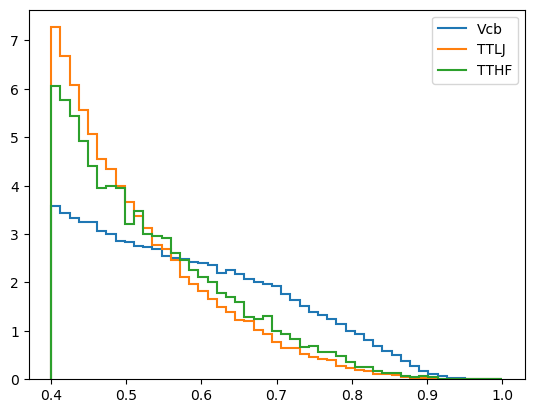

In [15]:
idx = 0
thr = 0.6
#w   = [results[idx].metrics["w0"], results[idx].metrics["w1"],
#       results[idx].metrics["w2"], results[idx].metrics["w3"]]  # thr와 같은 idx의 w 사용 권장
w = [1, 1.97, 19.3, 7.39]
#print(f"thr is {results[idx].metrics['thr']}, Z is {results[idx].metrics['best_Z']}")
#print(w)
#w = [results[0].metrics["w0"], results[0].metrics["w1"], results[0].metrics["w2"], results[0].metrics["w3"]]
Vcb_Prob = log_prob_to_weighted_prob(np.vstack([Vcb['classif_0'], Vcb['classif_1'], Vcb['classif_2'], Vcb['classif_3']]).T,w)
TTLJ_Prob = log_prob_to_weighted_prob(np.vstack([TTLJ['classif_0'], TTLJ['classif_1'], TTLJ['classif_2'], TTLJ['classif_3']]).T,w)

bkg_edges = auto_bins(
    TTLJ_Prob[TTLJ_Prob < thr],
    w=TTLJ['weight_base'][TTLJ_Prob < thr],
    min_bins=20, max_bins=30,
    return_hist=False,
    value_range=(0.0, thr)     # ↑ 마지막 edge를 정확히 thr로
)

# 2) Thr 위: 시그널 쪽에서 비닝
sig_edges = auto_bins(
    Vcb_Prob[Vcb_Prob >= thr],
    w=Vcb['weight_base'][Vcb_Prob >= thr],
    min_bins=5, max_bins=5,
    return_hist=False,
    value_range=(thr, 1.0)     # ↓ 첫 edge를 정확히 thr로
)
print(bkg_edges)
print(sig_edges)
edges = np.unique(np.concatenate([bkg_edges[:-1], sig_edges]))
print(edges)
edges = np.linspace(0.4, 1, 50)

Vcb_hist,  _ = np.histogram(Vcb_Prob,  bins=edges, weights=Vcb['weight_base'])
TTLJ_hist, _ = np.histogram(TTLJ_Prob, bins=edges, weights=TTLJ['weight_base'])
TTHF_hist, _ = np.histogram(TTLJ_Prob[TTLJ['TTBB_Mask']], bins=edges, weights=TTLJ['weight_base'][TTLJ['TTBB_Mask']])
import matplotlib.pyplot as plt
import mplhep as hep
print(edges)

hep.histplot(Vcb_hist*100,  bins=edges, histtype="step", label="Vcb", density=True)
hep.histplot(TTLJ_hist, bins=edges, histtype="step", label="TTLJ", density=True)
hep.histplot(TTHF_hist, bins=edges, histtype="step", label="TTHF", density=True)
#log scale
#plt.yscale("log")
#x limit
plt.legend()
plt.show()


In [16]:
import os
import numpy as np
from dataclasses import dataclass
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# --- your existing bits (unchanged) ---
bins = np.linspace(0, 1, 100)
grids = get_grids(1, 0.01, 2, res=100)  # 1D 그리드로 변경
@dataclass
class GridScanRecord:
    weights: np.ndarray   # (K,)
    best_Z: float
    best_thr: float
    best_S: float
    best_B: float
    best_rel_b: float
    i_best: int

# assumes you already have:
# - grids
# - Vcb, TTLJ dicts with arrays
# - log_prob_to_weighted_prob(...)
# - _cum_from_right(...)
# - asimov_Z(...)

def _scan_one_grid(grid):
    # 1) weights
    w = np.insert(grid, 0, 1)

    # 2) probabilities
    Vcb_prob  = log_prob_to_weighted_prob(
        np.vstack([Vcb['binary_0'], Vcb['binary_1']]).T, w
    )
    TTLJ_prob = log_prob_to_weighted_prob(
        np.vstack([TTLJ['binary_0'], TTLJ['binary_1']]).T, w
    )

    # 3) nominal hists
    Vcb_hist,  _ = np.histogram(Vcb_prob,  bins=bins, weights=Vcb['weight_base'])
    TTLJ_hist, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_base'])

    # 4) syst "up" hists (background)
    Vcb_hist_cferr1_up, _ = np.histogram(Vcb_prob,  bins=bins, weights=Vcb['weight_cferr1_up'])
    Vcb_hist_cferr2_up, _ = np.histogram(Vcb_prob,  bins=bins, weights=Vcb['weight_cferr2_up'])
    Vcb_hist_ttbb_up,   _ = np.histogram(Vcb_prob,  bins=bins, weights=Vcb['weight_ttbb_up'])
    Vcb_hist_ttcc_up,   _ = np.histogram(Vcb_prob,  bins=bins, weights=Vcb['weight_ttcc_up'])

    TTLJ_hist_cferr1_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_cferr1_up'])
    TTLJ_hist_cferr2_up, _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_cferr2_up'])
    TTLJ_hist_ttbb_up,   _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_ttbb_up'])
    TTLJ_hist_ttcc_up,   _ = np.histogram(TTLJ_prob, bins=bins, weights=TTLJ['weight_ttcc_up'])

    # 5) cumulatives (right-tail scan)
    S_cum = _cum_from_right(Vcb_hist)
    B_cum = _cum_from_right(TTLJ_hist)

    B_cferr1_cum = _cum_from_right(TTLJ_hist_cferr1_up)
    B_cferr2_cum = _cum_from_right(TTLJ_hist_cferr2_up)
    B_ttbb_cum   = _cum_from_right(TTLJ_hist_ttbb_up)
    B_ttcc_cum   = _cum_from_right(TTLJ_hist_ttcc_up)

    d_cferr1 = B_cferr1_cum - B_cum
    d_cferr2 = B_cferr2_cum - B_cum
    d_ttbb   = B_ttbb_cum   - B_cum
    d_ttcc   = B_ttcc_cum   - B_cum

    sigma_b = np.sqrt(d_cferr1**2 + d_cferr2**2 + d_ttbb**2 + d_ttcc**2)
    rel_b   = sigma_b / np.maximum(B_cum, 1e-12)

    # 6) Asimov Z scan
    Z_curve = asimov_Z(S_cum, B_cum, rel_b=rel_b, include_systematics=True)
    i_best  = int(np.argmax(Z_curve))

    rec = GridScanRecord(
        weights=w,
        best_Z=float(Z_curve[i_best]),
        best_thr=float(bins[i_best]),
        best_S=float(S_cum[i_best]),
        best_B=float(B_cum[i_best]),
        best_rel_b=float(rel_b[i_best]),
        i_best=i_best
    )

    # return hists for optional plotting in the main process
    return rec, Vcb_hist, TTLJ_hist, grid

# ----------------- run in parallel -----------------
results = []
plots_data = []  # (Vcb_hist, TTLJ_hist, grid) for optional plotting later


if __name__ == "__main__":
    max_workers = os.cpu_count()//2 or 1
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_scan_one_grid, grid) for grid in grids]
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Grid scan"):
            rec, Vcb_hist, TTLJ_hist, grid = fut.result()
            results.append(rec)
            plots_data.append((Vcb_hist, TTLJ_hist, grid))


Grid scan: 100%|██████████| 100/100 [00:15<00:00,  6.39it/s]


In [17]:
results = sorted(results, key=lambda r: r.best_Z, reverse=True)
results

[GridScanRecord(weights=array([1.        , 0.91454545]), best_Z=0.5904911936998053, best_thr=0.9797979797979799, best_S=8.768218994140625, best_B=92.15625, best_rel_b=0.1178763002332425, i_best=97),
 GridScanRecord(weights=array([1.        , 1.87939394]), best_Z=0.5904413024564888, best_thr=0.9595959595959597, best_S=8.677825927734375, best_B=91.21875, best_rel_b=0.1174060511701914, i_best=95),
 GridScanRecord(weights=array([1.        , 0.45222222]), best_Z=0.5899533753692547, best_thr=0.98989898989899, best_S=8.78131103515625, best_B=92.40625, best_rel_b=0.11793960606375099, i_best=98),
 GridScanRecord(weights=array([1.       , 1.7989899]), best_Z=0.5897429873990689, best_thr=0.9595959595959597, best_S=9.32025146484375, best_B=100.9375, best_rel_b=0.11610643173115885, i_best=95),
 GridScanRecord(weights=array([1.       , 1.3969697]), best_Z=0.5890072377341494, best_thr=0.9696969696969697, best_S=8.657684326171875, best_B=91.15625, best_rel_b=0.11754798311703779, i_best=96),
 GridScanR

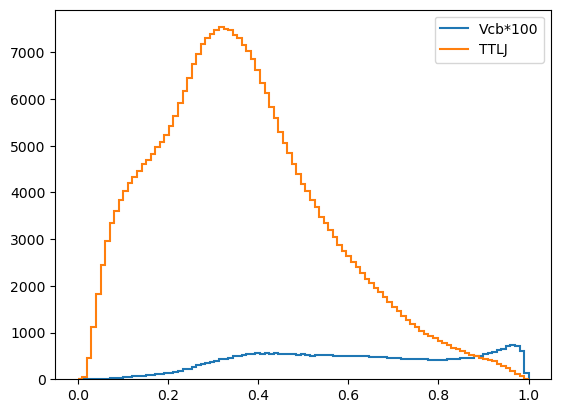

In [51]:
Vcb_Prob = log_prob_to_weighted_prob(np.vstack([Vcb['binary_0'],Vcb['binary_1']]).T,[1.   , 1.  ])
TTLJ_Prob = log_prob_to_weighted_prob(np.vstack([TTLJ['binary_0'],TTLJ['binary_1']]).T,[1.  , 1.])

Vcb_hist,  _ = np.histogram(Vcb_Prob,  bins=bins, weights=Vcb['weight_base'])
TTLJ_hist, _ = np.histogram(TTLJ_Prob, bins=bins, weights=TTLJ['weight_base'])
TTHF_hist, _ = np.histogram(TTLJ_Prob[TTLJ['TTBB_Mask']], bins=bins, weights=TTLJ['weight_base'][TTLJ['TTBB_Mask']])
import matplotlib.pyplot as plt
import mplhep as hep

hep.histplot(Vcb_hist*100,  bins=bins, histtype="step", label="Vcb*100")
hep.histplot(TTLJ_hist, bins=bins, histtype="step", label="TTLJ")
#hep.histplot(TTHF_hist, bins=bins, histtype="step", label="TTHF")
#log scale

plt.legend()
plt.show()

In [35]:
import awkward_cpp as ak
import uproot
tr_TTLJ = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016postVFP/Vcb_CTag_SPANet/Central_Syst/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree")
arr_TTLJ = tr_TTLJ.arrays(library="ak")
tr_WtoCB = uproot.open("/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016postVFP/Vcb_CTag_SPANet/Central_Syst/Vcb_WtoCB_powheg.root:Mu/Central/Result_Tree")
arr_WtoCB = tr_WtoCB.arrays(library="ak")


FileNotFoundError: [Errno 2] No such file or directory: '/gv0/Users/isyoon/Vcb_Post_Analysis/Sample/2016postVFP/Vcb_CTag_SPANet/Central_Syst/Vcb_WtoCB_powheg.root'

In [ ]:
genTtbarId = arr_TTLJ['genTtbarId']
mask = (genTtbarId % 100 >= 41) & (genTtbarId % 100 <= 45) 
mask = mask | ((genTtbarId % 100 >= 51) & (genTtbarId % 100 <= 55))

In [33]:
import numpy as np
hist, edges = np.histogram(arr_Vcb["mva_hf_score"][mask], bins=np.linspace(0,1, 60))

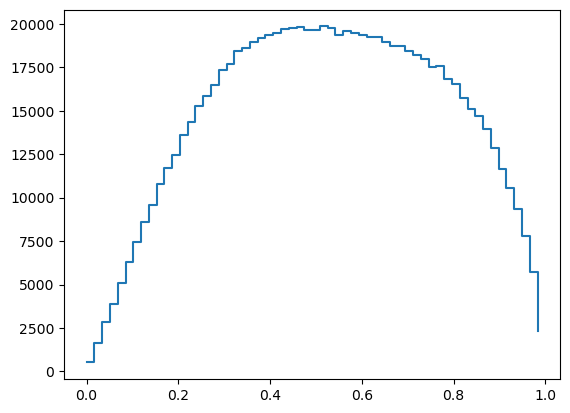

In [34]:
from matplotlib import pyplot as plt
plt.step(edges[:-1], hist, where="post")
plt.show()